# SuperSimpleNet MVTec Head Fine-Tune

Гипотеза: после базового unsupervised-обучения SuperSimpleNet на нормальных MVTec-изображениях имеет смысл отдельно дообучать головы на небольшой порции реальных дефектов.

Почему именно так:
- В оригинальной SuperSimpleNet классификационная голова отвечает за image-level score и должна ловить глобальный контекст, а сегментационная голова отвечает за карту аномалий.
- В статье про режимы обучения SuperSimpleNet явно поддерживает weak / mixed / fully supervised режимы: image-level дефекты могут учить detection/classification ветку, а маски позволяют доучивать segmentation ветку.
- Поэтому ниже сравниваются три состояния одной и той же базовой модели: до fine-tune, после fine-tune только classification head, после fine-tune всего `segdec` блока на масках.

Важно: это не официальный MVTec-протокол, потому что часть `test` используется как имитация накопленных продовых дефектов для fine-tune. Для проверки гипотезы это полезнее: мы проверяем, помогает ли отдельная адаптация голов, не смешивая train/fine-tune/holdout.

In [1]:
import copy
import csv
import json
import os
import random
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
import torch.optim as optim
from torch.nn.utils import clip_grad_norm_
from torch.optim.lr_scheduler import MultiStepLR
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.transforms import InterpolationMode

from anomalib.metrics.aupro import _AUPRO as DirectAUPRO
from anomalib.models.image.supersimplenet.loss import SSNLoss
from anomalib.models.image.supersimplenet.torch_model import SupersimplenetModel


c:\Users\AERO\Desktop\master_work\FastFlow\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
run_note = """
Цель запуска: сравнить baseline SuperSimpleNet на MVTecAD с дообучением голов.
Ключевые настройки: base model из ssn_baseline/try_1; classifier-head only, weak MIL segdec, supervised segdec.
Комментарий: основной протокол сравнения держим компактным: image AUROC/AP и pixel AUPRO на holdout.
""".strip()


def save_run_note(log_dir, filename="run_note.txt"):
    os.makedirs(log_dir, exist_ok=True)
    with open(os.path.join(log_dir, filename), "w", encoding="utf-8") as f:
        f.write(run_note.strip() + "\n")


In [2]:
def seed_everything(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False


def make_torch_generator(seed):
    generator = torch.Generator()
    generator.manual_seed(seed)
    return generator


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    random.seed(worker_seed)
    np.random.seed(worker_seed)


def make_dataloader(dataset, batch_size, shuffle=False, num_workers=0, seed=None, **kwargs):
    loader_seed = random_seed if seed is None else seed
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        worker_init_fn=seed_worker,
        generator=make_torch_generator(loader_seed),
        **kwargs,
    )


random_seed = 42
seed_everything(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(torch.cuda.current_device()))

cuda
NVIDIA GeForce RTX 3070 Ti Laptop GPU


## Конфигурация эксперимента

Основные метрики: `image_roc_auc_raw` для image-level detection и `pixel_aupro` для localization/segmentation. Это соответствует протоколу SuperSimpleNet для MVTec-style датасетов: AUROC для обнаружения, AUPRO для локализации.


In [ ]:
dataset_path = Path("datasets") / "MVTecAD"
class_name = "hazelnut"
defect_groups = None
image_size = 256

experiment_name = "ssn_head_finetune"
experiment_try = "try_3"
log_dir = Path("../experiments") / class_name / experiment_name / experiment_try
log_dir.mkdir(parents=True, exist_ok=True)
save_run_note(log_dir)
reproducibility_config = {
    "random_seed": random_seed,
    "python_hash_seed": os.environ.get("PYTHONHASHSEED"),
    "cudnn_benchmark": torch.backends.cudnn.benchmark,
    "cudnn_deterministic": torch.backends.cudnn.deterministic,
    "torch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_device": torch.cuda.get_device_name(torch.cuda.current_device()) if torch.cuda.is_available() else None,
    "experiment_try": experiment_try,
}
with open(log_dir / "reproducibility_config.json", "w") as f:
    json.dump(reproducibility_config, f, indent=2)

quality_metric_names = ["image_roc_auc_raw", "image_avg_precision_raw", "pixel_aupro"]

base_experiment_name = "ssn_baseline"
base_experiment_try = "try_1"
base_model_path = Path("../experiments") / class_name / base_experiment_name / base_experiment_try / "trained_model.pth"
reuse_existing_base_model = True
force_retrain_base_model = False
train_base_if_missing = True

num_base_epochs = 70
base_batch_size = 10
base_learning_rate = 1e-4
base_weight_decay = 1e-5
base_val_fraction = 0.15
base_early_stopping_patience = 10

head_finetune_fraction = 0.25
normal_per_anomaly_for_head = 1.0

classification_head_epochs = 6
classification_head_lr = 3e-5
classification_head_weight_decay = 1e-4
classification_head_batch_size = 8

run_weak_segdec_finetune = True
weak_segdec_epochs = classification_head_epochs
weak_segdec_lr = 5e-6
weak_segdec_weight_decay = 1e-5
weak_segdec_batch_size = classification_head_batch_size
weak_topk_ratio = 0.01
weak_score_loss_weight = 1.0
weak_map_loss_weight = 0.5
weak_normal_map_loss_weight = 0.05

run_supervised_segdec_finetune = True
supervised_segdec_epochs = 8
supervised_segdec_lr = 2e-5
supervised_segdec_weight_decay = 1e-5
supervised_segdec_batch_size = 6
use_synthetic_during_supervised_finetune = False

max_visualizations_per_group = 2
print(log_dir.resolve())


In [4]:
def get_augmented_transformer(image_size):
    return transforms.Compose([
        transforms.RandomResizedCrop((image_size, image_size), scale=(0.9, 1.0), ratio=(1.0, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


def get_transformer(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


def get_mask_transformer(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size), interpolation=InterpolationMode.NEAREST),
        transforms.ToTensor(),
    ])


def denormalize_image(tensor):
    denorm = transforms.Normalize(
        mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
        std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
    )
    return torch.clamp(denorm(tensor.detach().cpu()), 0, 1)


base_train_transform = get_transformer(image_size)
head_cls_transform = get_augmented_transformer(image_size)
eval_transform = get_transformer(image_size)
mask_transform = get_mask_transformer(image_size)

## Датасеты и разбиение

`train/good` используется только для базового unsupervised-обучения. Реальные MVTec-дефекты из `test` делятся на:
- `head_finetune_dataset`: имитация накопленных размеченных дефектов;
- `holdout_dataset`: финальная проверка before/after.

Для mask fine-tune аугментации отключены, потому что image/mask должны трансформироваться синхронно.

In [5]:
IMG_EXTENSIONS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")


def list_images(folder):
    folder = Path(folder)
    return sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTENSIONS])


class NormalImageDataset(Dataset):
    def __init__(self, root_dir, category, transform=None):
        self.root_dir = Path(root_dir) / category / "train" / "good"
        self.transform = transform
        self.image_paths = list_images(self.root_dir)
        if not self.image_paths:
            raise ValueError(f"No normal train images found in {self.root_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image


class MVTecPathDataset(Dataset):
    def __init__(self, items, img_transform=None, mask_transform=None):
        self.items = list(items)
        self.img_transform = img_transform
        self.mask_transform = mask_transform or transforms.ToTensor()

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        image_path = Path(item["image_path"])
        image = Image.open(image_path).convert("RGB")
        original_size = image.size

        if item["mask_path"] is None:
            mask = Image.new("L", original_size, 0)
        else:
            mask = Image.open(item["mask_path"]).convert("L")

        if self.img_transform:
            image = self.img_transform(image)
        if self.mask_transform:
            mask = self.mask_transform(mask)
        mask = (mask > 0.5).float()

        return (
            image,
            torch.tensor(float(item["label"]), dtype=torch.float32),
            mask,
            item["name"],
            item["defect_type"],
        )


def resolve_mask_path(root_dir, category, defect_type, image_path):
    if defect_type == "good":
        return None
    gt_dir = Path(root_dir) / category / "ground_truth" / defect_type
    candidate = gt_dir / f"{image_path.stem}_mask{image_path.suffix}"
    if candidate.exists():
        return candidate
    matches = sorted(gt_dir.glob(f"{image_path.stem}_mask.*"))
    if matches:
        return matches[0]
    raise FileNotFoundError(f"Mask was not found for {image_path}")


def build_mvtec_test_items(root_dir, category, defect_groups=None):
    test_dir = Path(root_dir) / category / "test"
    groups = sorted([p.name for p in test_dir.iterdir() if p.is_dir()])
    if defect_groups is not None:
        groups = [group for group in groups if group in set(defect_groups)]

    items = []
    for group in groups:
        for image_path in list_images(test_dir / group):
            label = 0 if group == "good" else 1
            mask_path = resolve_mask_path(root_dir, category, group, image_path)
            items.append({
                "image_path": str(image_path),
                "mask_path": None if mask_path is None else str(mask_path),
                "label": label,
                "defect_type": group,
                "name": f"{group}_{image_path.name}",
            })
    if not items:
        raise ValueError(f"No test images found for {category}")
    return items


def split_items_for_head_finetune(items, finetune_fraction=0.35, normal_per_anomaly=1.0, seed=42):
    rng = random.Random(seed)
    anomaly_by_type = defaultdict(list)
    good_items = []

    for item in items:
        if item["label"] == 1:
            anomaly_by_type[item["defect_type"]].append(item)
        else:
            good_items.append(item)

    fine_items = []
    holdout_items = []
    for defect_type, group_items in sorted(anomaly_by_type.items()):
        group_items = sorted(group_items, key=lambda x: x["image_path"])
        rng.shuffle(group_items)
        if len(group_items) == 1:
            n_fine = 1
        else:
            n_fine = int(round(len(group_items) * finetune_fraction))
            n_fine = min(max(1, n_fine), len(group_items) - 1)
        fine_items.extend(group_items[:n_fine])
        holdout_items.extend(group_items[n_fine:])

    good_items = sorted(good_items, key=lambda x: x["image_path"])
    rng.shuffle(good_items)
    n_good_fine = int(round(len(fine_items) * normal_per_anomaly))
    if len(good_items) > 1:
        n_good_fine = min(max(1, n_good_fine), len(good_items) - 1)
    else:
        n_good_fine = len(good_items)
    fine_items.extend(good_items[:n_good_fine])
    holdout_items.extend(good_items[n_good_fine:])

    rng.shuffle(fine_items)
    rng.shuffle(holdout_items)

    holdout_labels = {item["label"] for item in holdout_items}
    if holdout_labels != {0, 1}:
        raise ValueError("Holdout split must contain both normal and anomalous images")
    return fine_items, holdout_items


def summarize_items(items, title):
    counts = Counter(item["defect_type"] for item in items)
    labels = Counter(item["label"] for item in items)
    print(f"{title}: {len(items)} images | labels={dict(labels)} | groups={dict(counts)}")


all_test_items = build_mvtec_test_items(dataset_path, class_name, defect_groups)
head_items, holdout_items = split_items_for_head_finetune(
    all_test_items,
    finetune_fraction=head_finetune_fraction,
    normal_per_anomaly=normal_per_anomaly_for_head,
    seed=random_seed,
)

summarize_items(all_test_items, "All MVTec test")
summarize_items(head_items, "Head fine-tune split")
summarize_items(holdout_items, "Holdout split")

base_full_dataset = NormalImageDataset(dataset_path, class_name, transform=base_train_transform)
base_indices = list(range(len(base_full_dataset)))
base_train_idx, base_val_idx = train_test_split(
    base_indices,
    test_size=base_val_fraction,
    random_state=random_seed,
    shuffle=True,
)
base_train_dataset = Subset(base_full_dataset, base_train_idx)
base_val_dataset = Subset(base_full_dataset, base_val_idx)

head_cls_dataset = MVTecPathDataset(head_items, img_transform=head_cls_transform, mask_transform=mask_transform)
head_mask_dataset = MVTecPathDataset(head_items, img_transform=eval_transform, mask_transform=mask_transform)
holdout_dataset = MVTecPathDataset(holdout_items, img_transform=eval_transform, mask_transform=mask_transform)

print(f"Base train normals: {len(base_train_dataset)} | base val normals: {len(base_val_dataset)}")

All MVTec test: 110 images | labels={1: 70, 0: 40} | groups={'crack': 18, 'cut': 17, 'good': 40, 'hole': 18, 'print': 17}
Head fine-tune split: 48 images | labels={1: 24, 0: 24} | groups={'print': 6, 'good': 24, 'hole': 6, 'cut': 6, 'crack': 6}
Holdout split: 62 images | labels={0: 16, 1: 46} | groups={'good': 16, 'crack': 12, 'hole': 12, 'print': 11, 'cut': 11}
Base train normals: 332 | base val normals: 59


In [6]:
def img2mask(img):
    mask = img if not isinstance(img, torch.Tensor) else img.detach().cpu()
    if isinstance(mask, torch.Tensor):
        mask = mask.squeeze()
        if mask.ndim != 2:
            raise ValueError(f"Wrong mask dimensions: {tuple(mask.shape)}")
        return mask
    mask = np.squeeze(mask)
    if mask.ndim != 2:
        raise ValueError(f"Wrong mask dimensions: {mask.shape}")
    return mask


def safe_roc_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))


def safe_average_precision(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))


def safe_aupro(pred_maps, target_maps, fpr_limit=0.3, num_thresholds=100):
    preds = torch.stack([img2mask(pred).float().cpu() for pred in pred_maps])
    targets = torch.stack([(img2mask(target) > 0.5).long().cpu() for target in target_maps])
    if targets.max().item() == targets.min().item():
        return float("nan")
    metric = DirectAUPRO(fpr_limit=fpr_limit, num_thresholds=num_thresholds)
    return float(metric(preds, targets).detach().cpu().item())


def sigmoid_scalar(value):
    return float(torch.sigmoid(torch.as_tensor(value)).item())


def plot_training_curves(metrics, metric_names, out_dir, filename, log_y=False):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(10, 6))
    for metric, metric_name in zip(metrics, metric_names):
        plt.plot(metric, label=metric_name, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    if log_y:
        plt.yscale("log")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(out_dir / filename)
    plt.show()


def save_visualization(image, anomaly_map, true_mask, save_path, title):
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    image = denormalize_image(image.squeeze(0))
    image_np = np.asarray(transforms.ToPILImage()(image))
    anomaly_np = img2mask(anomaly_map).numpy()
    mask_np = img2mask(true_mask).numpy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(image_np)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(image_np)
    axes[1].imshow(mask_np, cmap="gray", alpha=0.65, vmin=0, vmax=1)
    axes[1].set_title("GT mask")
    axes[1].axis("off")

    axes[2].imshow(image_np)
    heatmap = axes[2].imshow(anomaly_np, cmap="jet", alpha=0.65, vmin=0, vmax=1)
    axes[2].set_title(title)
    axes[2].axis("off")
    plt.colorbar(heatmap, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(save_path)
    plt.close(fig)


## Базовое обучение SuperSimpleNet

Если `base_model_path` существует, она будет использована как baseline. Иначе базовая модель обучится в новом логе только на `train/good` с синтетическими латентными аномалиями, как в unsupervised-режиме SuperSimpleNet.

In [7]:
def freeze_feature_extractor(model):
    frozen_params_num = 0
    if hasattr(model, "feature_extractor"):
        for param in model.feature_extractor.parameters():
            param.requires_grad = False
            frozen_params_num += param.numel()
    print(f"Parameters frozen: {frozen_params_num}")


def get_trainable_parameters(model):
    params = []
    count = 0
    for _, param in model.named_parameters():
        if param.requires_grad:
            params.append(param)
            count += param.numel()
    print(f"Trainable parameters: {count}")
    return params


def forward_normal_training_loss_path(model, images, criterion, device):
    features = model.feature_extractor(images)
    adapted = model.adaptor(features)
    dummy_masks = torch.zeros((images.shape[0], images.shape[-2], images.shape[-1]), device=device)
    dummy_labels = torch.zeros((images.shape[0],), device=device)
    target_mask = model.downsample_mask(dummy_masks, *features.shape[-2:])
    target_label = dummy_labels.to(torch.float32)
    train_features, target_mask, target_label = model.anomaly_generator(adapted, target_mask, target_label)
    pred_map, pred_score = model.segdec(train_features)
    pred_score = pred_score.view(-1)
    target_label = target_label.view(-1)
    return criterion(pred_map=pred_map, pred_score=pred_score, target_mask=target_mask, target_label=target_label)


def train_unsupervised_base_model(
    model,
    train_dataset,
    val_dataset,
    num_epochs=70,
    learning_rate=1e-4,
    weight_decay=1e-5,
    batch_size=10,
    device=device,
    log_dir=log_dir,
    early_stopping_patience=10,
):
    model = model.to(device)
    criterion = SSNLoss()
    base_log_dir = Path(log_dir) / "before_head_finetune"
    base_log_dir.mkdir(parents=True, exist_ok=True)

    freeze_feature_extractor(model)
    get_trainable_parameters(model)
    optimizer = optim.AdamW([
        {"params": model.adaptor.parameters(), "lr": learning_rate},
        {"params": model.segdec.parameters(), "lr": learning_rate * 2, "weight_decay": weight_decay},
    ])
    scheduler = MultiStepLR(
        optimizer,
        milestones=[max(1, int(num_epochs * 0.8)), max(1, int(num_epochs * 0.9))],
        gamma=0.4,
    )

    train_loader = make_dataloader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, seed=random_seed)
    val_loader = make_dataloader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, seed=random_seed)

    metrics = {"Train_Loss": [], "Validation_Loss": []}
    best_state = None
    best_val = float("inf")
    epochs_without_improvement = 0

    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0.0
        for images in tqdm(train_loader, desc=f"Base Train {epoch + 1}/{num_epochs}", leave=False):
            images = images.to(device)
            optimizer.zero_grad()
            loss = forward_normal_training_loss_path(model, images, criterion, device)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        scheduler.step()
        avg_train_loss = total_train_loss / max(1, len(train_loader))
        metrics["Train_Loss"].append(avg_train_loss)

        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for images in tqdm(val_loader, desc=f"Base Val {epoch + 1}/{num_epochs}", leave=False):
                images = images.to(device)
                loss = forward_normal_training_loss_path(model, images, criterion, device)
                total_val_loss += loss.item()
        avg_val_loss = total_val_loss / max(1, len(val_loader))
        metrics["Validation_Loss"].append(avg_val_loss)

        print(f"Base epoch {epoch + 1}/{num_epochs} | train={avg_train_loss:.6f} | val={avg_val_loss:.6f}")

        if avg_val_loss < best_val:
            best_val = avg_val_loss
            epochs_without_improvement = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            epochs_without_improvement += 1

        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": copy.deepcopy(model.state_dict()),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "metrics": metrics,
        }
        torch.save(checkpoint, base_log_dir / "checkpoint.pth")

        if epochs_without_improvement >= early_stopping_patience:
            print(f"Base early stopping at epoch {epoch + 1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    torch.save(model, base_log_dir / "trained_model.pth")
    torch.save(model.state_dict(), base_log_dir / "trained_model_weights.pth")
    plot_training_curves(
        [metrics["Train_Loss"], metrics["Validation_Loss"]],
        ["Train_Loss", "Validation_Loss"],
        base_log_dir,
        "base_losses.png",
    )
    return model, metrics


def load_or_train_base_model():
    if reuse_existing_base_model and not force_retrain_base_model and base_model_path.exists():
        print(f"Loading baseline model from {base_model_path}")
        model = torch.load(base_model_path, weights_only=False, map_location=device)
        return model.to(device), {"source": str(base_model_path)}

    if not train_base_if_missing:
        raise FileNotFoundError(f"Baseline model not found or retraining disabled: {base_model_path}")

    print("Training baseline model from scratch in the new experiment log")
    seed_everything(random_seed)
    model = SupersimplenetModel(
        backbone="wide_resnet50_2.tv_in1k",
        layers=["layer2", "layer3"],
        perlin_threshold=0.2,
        stop_grad=True,
    )
    model, metrics = train_unsupervised_base_model(
        model=model,
        train_dataset=base_train_dataset,
        val_dataset=base_val_dataset,
        num_epochs=num_base_epochs,
        learning_rate=base_learning_rate,
        weight_decay=base_weight_decay,
        batch_size=base_batch_size,
        device=device,
        log_dir=log_dir,
        early_stopping_patience=base_early_stopping_patience,
    )
    return model, metrics

In [ ]:
def evaluate_model(model, dataset, out_dir, run_name, device=device, max_visualizations_per_group=2):
    out_dir = Path(out_dir) / run_name
    vis_dir = out_dir / "visualizations"
    out_dir.mkdir(parents=True, exist_ok=True)
    vis_dir.mkdir(parents=True, exist_ok=True)

    model = model.to(device)
    model.eval()

    rows = []
    image_labels = []
    image_scores_raw = []
    image_scores_sigmoid = []
    pixel_label_maps = []
    pixel_score_maps = []
    vis_counts = Counter()

    with torch.no_grad():
        for idx in tqdm(range(len(dataset)), desc=f"Evaluate {run_name}", leave=False):
            image, label, mask, name, defect_type = dataset[idx]
            image = image.unsqueeze(0).to(device)
            output = model(image)
            anomaly_map = torch.sigmoid(output.anomaly_map).detach().cpu().squeeze()
            raw_score = float(output.pred_score.detach().cpu().view(-1)[0])
            sigmoid_score = sigmoid_scalar(raw_score)

            mask_2d = img2mask(mask)
            pixel_label_map = (mask_2d > 0.5).float().cpu()
            pixel_score_map = anomaly_map.float().cpu()
            pixel_label_maps.append(pixel_label_map)
            pixel_score_maps.append(pixel_score_map)
            image_labels.append(int(label.item()))
            image_scores_raw.append(raw_score)
            image_scores_sigmoid.append(sigmoid_score)

            rows.append({
                "name": name,
                "defect_type": defect_type,
                "label": int(label.item()),
                "raw_pred_score": raw_score,
                "sigmoid_pred_score": sigmoid_score,
            })

            if vis_counts[defect_type] < max_visualizations_per_group:
                save_visualization(
                    image,
                    anomaly_map,
                    mask_2d,
                    vis_dir / f"{idx:03d}_{name}",
                    title=f"{run_name} | score={sigmoid_score:.3f}",
                )
                vis_counts[defect_type] += 1

    metrics = {
        "image_roc_auc_raw": safe_roc_auc(image_labels, image_scores_raw),
        "image_avg_precision_raw": safe_average_precision(image_labels, image_scores_raw),
        "pixel_aupro": safe_aupro(pixel_score_maps, pixel_label_maps),
        "num_images": len(image_labels),
        "num_good": int(sum(1 for label in image_labels if label == 0)),
        "num_anomaly": int(sum(1 for label in image_labels if label == 1)),
    }

    with open(out_dir / "per_image_scores.csv", "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["name", "defect_type", "label", "raw_pred_score", "sigmoid_pred_score"])
        writer.writeheader()
        writer.writerows(rows)

    with open(out_dir / "metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    print(run_name)
    for key in quality_metric_names + ["num_images", "num_good", "num_anomaly"]:
        print(f"  {key}: {metrics.get(key)}")
    return metrics, rows


## Оценка baseline до fine-tune

Training baseline model from scratch in the new experiment log
Parameters frozen: 24862528
Trainable parameters: 8856835


Base epoch 1/70 | train=1.505438 | val=1.107393


Base epoch 2/70 | train=1.148625 | val=1.135849


Base epoch 3/70 | train=1.080152 | val=1.157721


Base epoch 4/70 | train=1.064086 | val=1.042981


...

Base epoch 66/70 | train=0.004612 | val=0.027242


Base epoch 67/70 | train=0.004564 | val=0.029857


Base epoch 68/70 | train=0.005059 | val=0.047748


Base epoch 69/70 | train=0.005701 | val=0.024669


Base epoch 70/70 | train=0.006533 | val=0.022545


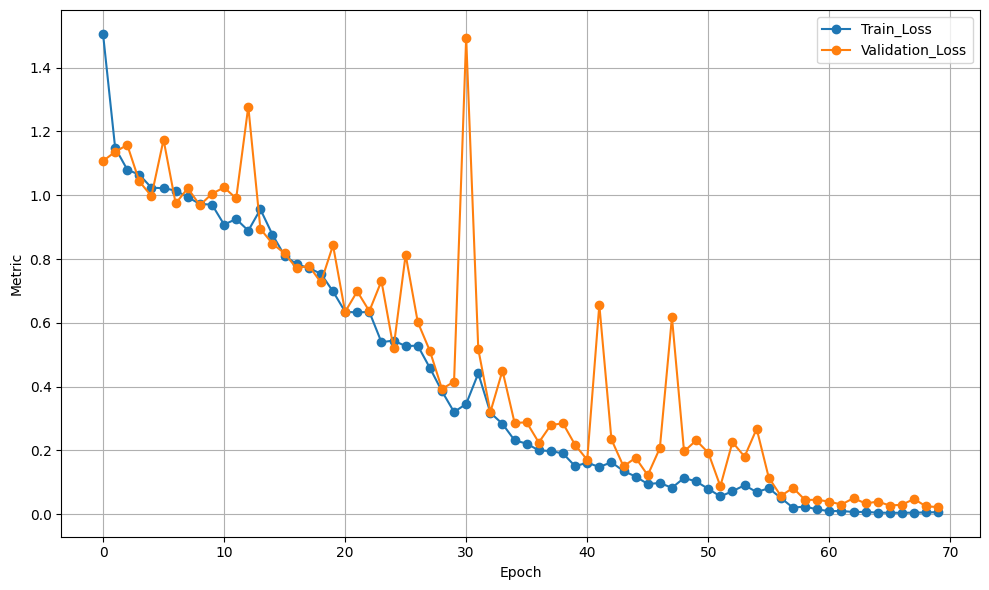

before_head_finetune
  image_roc_auc_raw: 0.9877717391304348
  image_avg_precision_raw: 0.9959984637381477
  image_roc_auc_sigmoid: 0.9877717391304348
  image_avg_precision_sigmoid: 0.9959984637381477
  pixel_roc_auc: 0.9803309016962684
  pixel_avg_precision: 0.5096283564776224
  pixel_aupro: 0.9317749738693237
  num_images: 62
  num_good: 16
  num_anomaly: 46


In [9]:
baseline_model, baseline_train_info = load_or_train_base_model()
baseline_metrics, baseline_rows = evaluate_model(
    baseline_model,
    holdout_dataset,
    out_dir=log_dir,
    run_name="before_head_finetune",
    device=device,
    max_visualizations_per_group=max_visualizations_per_group,
)

baseline_state = {key: value.detach().cpu().clone() for key, value in baseline_model.state_dict().items()}
del baseline_model
torch.cuda.empty_cache()

## Weak-supervised fine-tune

This block compares three weak-supervised variants on the same `head_cls_dataset`: classifier head only, full `segdec` trained only with image-level classification loss, and full `segdec` trained with the additional top-k/MIL loss on the anomaly map. Masks from the dataset are intentionally ignored in these three stages.


In [ ]:
def build_model_from_state(state_dict):
    model = SupersimplenetModel(
        backbone="wide_resnet50_2.tv_in1k",
        layers=["layer2", "layer3"],
        perlin_threshold=0.2,
        stop_grad=True,
    )
    model.load_state_dict(state_dict, strict=True)
    return model


def set_only_classifier_head_trainable(model):
    for param in model.parameters():
        param.requires_grad = False
    for param in model.segdec.cls_conv.parameters():
        param.requires_grad = True
    for param in model.segdec.cls_fc.parameters():
        param.requires_grad = True
    get_trainable_parameters(model)


def set_only_segdec_trainable(model):
    for param in model.parameters():
        param.requires_grad = False
    for param in model.segdec.parameters():
        param.requires_grad = True
    get_trainable_parameters(model)


def segdec_forward_from_images(model, images):
    with torch.no_grad():
        features = model.feature_extractor(images)
        adapted = model.adaptor(features)
    pred_map, pred_score = model.segdec(adapted.detach())
    return pred_map, pred_score.view(-1)


def classifier_head_logits(model, images):
    _, pred_score = segdec_forward_from_images(model, images)
    return pred_score


def segdec_forward_with_features(model, images):
    with torch.no_grad():
        features = model.feature_extractor(images)
        adapted = model.adaptor(features).detach()
    pred_map, pred_score = model.segdec(adapted)
    return adapted, pred_map, pred_score.view(-1)


def topk_mean_logits(pred_map, topk_ratio=0.01):
    flat_map = pred_map.reshape(pred_map.shape[0], -1)
    k = max(1, int(flat_map.shape[1] * topk_ratio))
    return flat_map.topk(k, dim=1).values.mean(dim=1)


def weak_map_mil_loss(pred_map, labels, topk_ratio=0.01):
    map_logits = topk_mean_logits(pred_map, topk_ratio=topk_ratio)
    return torch.nn.functional.binary_cross_entropy_with_logits(map_logits, labels.float().view(-1))


def normal_map_suppression_loss(pred_map, labels):
    normal_mask = labels.view(-1) == 0
    if not normal_mask.any():
        return torch.zeros((), device=pred_map.device)
    return torch.nn.functional.binary_cross_entropy_with_logits(
        pred_map[normal_mask],
        torch.zeros_like(pred_map[normal_mask]),
    )


def make_image_level_criterion(dataset, device=device):
    labels = [float(item["label"]) for item in dataset.items]
    normal_count = max(1, sum(1 for label in labels if label == 0.0))
    anomaly_count = max(1, sum(1 for label in labels if label == 1.0))
    pos_weight = torch.tensor([normal_count / anomaly_count], device=device)
    return torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)


def finetune_classifier_head(
    model,
    dataset,
    num_epochs=6,
    learning_rate=3e-5,
    weight_decay=1e-4,
    batch_size=8,
    device=device,
    log_dir=log_dir,
):
    model = model.to(device)
    set_only_classifier_head_trainable(model)
    head_log_dir = Path(log_dir) / "after_classification_head_finetune"
    head_log_dir.mkdir(parents=True, exist_ok=True)

    loader = make_dataloader(dataset, batch_size=batch_size, shuffle=True, num_workers=0, seed=random_seed)
    criterion = make_image_level_criterion(dataset, device=device)
    optimizer = optim.AdamW(get_trainable_parameters(model), lr=learning_rate, weight_decay=weight_decay)

    metrics = {"Head_Train_Loss": []}
    for epoch in range(num_epochs):
        model.train()
        model.feature_extractor.eval()
        model.adaptor.eval()
        model.segdec.seg_head.eval()
        model.segdec.cls_conv.train()
        model.segdec.cls_fc.train()

        total_loss = 0.0
        for images, labels, _, _, _ in tqdm(loader, desc=f"Cls Head {epoch + 1}/{num_epochs}", leave=False):
            images = images.to(device)
            labels = labels.to(device).view(-1)

            optimizer.zero_grad()
            logits = classifier_head_logits(model, images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / max(1, len(loader))
        metrics["Head_Train_Loss"].append(avg_loss)
        print(f"Classification head epoch {epoch + 1}/{num_epochs} | loss={avg_loss:.6f}")

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": copy.deepcopy(model.state_dict()),
            "optimizer_state_dict": optimizer.state_dict(),
            "metrics": metrics,
        }, head_log_dir / "checkpoint.pth")

    torch.save(model, head_log_dir / "trained_model.pth")
    torch.save(model.state_dict(), head_log_dir / "trained_model_weights.pth")
    plot_training_curves([metrics["Head_Train_Loss"]], ["Head_Train_Loss"], head_log_dir, "head_loss.png")
    return model, metrics


def finetune_weak_segdec_heads(
    model,
    dataset,
    num_epochs=6,
    learning_rate=5e-6,
    weight_decay=1e-5,
    batch_size=8,
    device=device,
    log_dir=log_dir,
    score_loss_weight=1.0,
    map_loss_weight=0.5,
    normal_map_loss_weight=0.05,
    topk_ratio=0.01,
):
    model = model.to(device)
    model.segdec.stop_grad = False
    set_only_segdec_trainable(model)
    head_log_dir = Path(log_dir) / "after_weak_segdec_mil_finetune"
    head_log_dir.mkdir(parents=True, exist_ok=True)

    loader = make_dataloader(dataset, batch_size=batch_size, shuffle=True, num_workers=0, seed=random_seed)
    score_criterion = make_image_level_criterion(dataset, device=device)
    optimizer = optim.AdamW(get_trainable_parameters(model), lr=learning_rate, weight_decay=weight_decay)
    scheduler = MultiStepLR(
        optimizer,
        milestones=[max(1, int(num_epochs * 0.75)), max(1, int(num_epochs * 0.9))],
        gamma=0.4,
    )

    metrics = {
        "Weak_Total_Loss": [],
        "Weak_Score_Loss": [],
        "Weak_Map_MIL_Loss": [],
        "Weak_Normal_Map_Loss": [],
    }
    for epoch in range(num_epochs):
        model.train()
        model.feature_extractor.eval()
        model.adaptor.eval()
        model.segdec.train()

        total_loss = 0.0
        total_score_loss = 0.0
        total_map_loss = 0.0
        total_normal_loss = 0.0
        for images, labels, _, _, _ in tqdm(loader, desc=f"Weak SegDec MIL {epoch + 1}/{num_epochs}", leave=False):
            images = images.to(device)
            labels = labels.to(device).view(-1)

            optimizer.zero_grad()
            _, pred_map, pred_score = segdec_forward_with_features(model, images)
            score_loss = score_criterion(pred_score, labels)
            map_loss = weak_map_mil_loss(pred_map, labels, topk_ratio=topk_ratio)
            normal_loss = normal_map_suppression_loss(pred_map, labels)
            loss = (
                score_loss_weight * score_loss
                + map_loss_weight * map_loss
                + normal_map_loss_weight * normal_loss
            )

            loss.backward()
            clip_grad_norm_(model.segdec.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            total_score_loss += score_loss.item()
            total_map_loss += map_loss.item()
            total_normal_loss += normal_loss.item()

        scheduler.step()
        denom = max(1, len(loader))
        metrics["Weak_Total_Loss"].append(total_loss / denom)
        metrics["Weak_Score_Loss"].append(total_score_loss / denom)
        metrics["Weak_Map_MIL_Loss"].append(total_map_loss / denom)
        metrics["Weak_Normal_Map_Loss"].append(total_normal_loss / denom)
        print(
            f"Weak SegDec MIL epoch {epoch + 1}/{num_epochs} | "
            f"loss={metrics['Weak_Total_Loss'][-1]:.6f} | "
            f"score={metrics['Weak_Score_Loss'][-1]:.6f} | "
            f"map={metrics['Weak_Map_MIL_Loss'][-1]:.6f} | "
            f"normal={metrics['Weak_Normal_Map_Loss'][-1]:.6f}"
        )

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": copy.deepcopy(model.state_dict()),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "metrics": metrics,
            "score_loss_weight": score_loss_weight,
            "map_loss_weight": map_loss_weight,
            "normal_map_loss_weight": normal_map_loss_weight,
            "topk_ratio": topk_ratio,
        }, head_log_dir / "checkpoint.pth")

    torch.save(model, head_log_dir / "trained_model.pth")
    torch.save(model.state_dict(), head_log_dir / "trained_model_weights.pth")
    plot_training_curves(
        [metrics["Weak_Total_Loss"], metrics["Weak_Score_Loss"], metrics["Weak_Map_MIL_Loss"], metrics["Weak_Normal_Map_Loss"]],
        ["Weak_Total_Loss", "Weak_Score_Loss", "Weak_Map_MIL_Loss", "Weak_Normal_Map_Loss"],
        head_log_dir,
        "weak_mil_losses.png",
    )
    return model, metrics


In [ ]:
seed_everything(random_seed)
classification_head_model = build_model_from_state(baseline_state)
classification_head_model, classification_head_train_metrics = finetune_classifier_head(
    model=classification_head_model,
    dataset=head_cls_dataset,
    num_epochs=classification_head_epochs,
    learning_rate=classification_head_lr,
    weight_decay=classification_head_weight_decay,
    batch_size=classification_head_batch_size,
    device=device,
    log_dir=log_dir,
)

classification_head_metrics, classification_head_rows = evaluate_model(
    classification_head_model,
    holdout_dataset,
    out_dir=log_dir,
    run_name="after_classification_head_finetune",
    device=device,
    max_visualizations_per_group=max_visualizations_per_group,
)

del classification_head_model
torch.cuda.empty_cache()

if run_weak_segdec_finetune:
    seed_everything(random_seed)
    weak_segdec_model = build_model_from_state(baseline_state)
    weak_segdec_model, weak_segdec_train_metrics = finetune_weak_segdec_heads(
        model=weak_segdec_model,
        dataset=head_cls_dataset,
        num_epochs=weak_segdec_epochs,
        learning_rate=weak_segdec_lr,
        weight_decay=weak_segdec_weight_decay,
        batch_size=weak_segdec_batch_size,
        device=device,
        log_dir=log_dir,
        score_loss_weight=weak_score_loss_weight,
        map_loss_weight=weak_map_loss_weight,
        normal_map_loss_weight=weak_normal_map_loss_weight,
        topk_ratio=weak_topk_ratio,
    )

    weak_segdec_metrics, weak_segdec_rows = evaluate_model(
        weak_segdec_model,
        holdout_dataset,
        out_dir=log_dir,
        run_name="after_weak_segdec_mil_finetune",
        device=device,
        max_visualizations_per_group=max_visualizations_per_group,
    )

    del weak_segdec_model
    torch.cuda.empty_cache()
else:
    weak_segdec_metrics = None


## Supervised fine-tune segmentation + classification heads on masks

This is the supervised upper-bound block. The feature extractor and adaptor stay frozen; only `segdec` is updated on the labeled fine-tune split. By default `use_synthetic_during_supervised_finetune=False`, because this block should measure real-mask supervised adaptation rather than mixing in SSN synthetic anomalies.


In [ ]:
def forward_mask_finetune_loss_path(model, images, masks, labels, criterion, device, use_synthetic=False):
    with torch.no_grad():
        features = model.feature_extractor(images)
        adapted = model.adaptor(features)

    masks = masks.squeeze(1) if masks.ndim == 4 else masks
    target_mask = model.downsample_mask(masks, *adapted.shape[-2:])
    target_label = labels.to(torch.float32).view(-1)

    if use_synthetic:
        train_features, target_mask, target_label = model.anomaly_generator(
            adapted.detach(),
            target_mask,
            target_label,
        )
    else:
        train_features = adapted.detach()

    pred_map, pred_score = model.segdec(train_features)
    pred_score = pred_score.view(-1)
    target_label = target_label.view(-1)
    return criterion(pred_map=pred_map, pred_score=pred_score, target_mask=target_mask, target_label=target_label)


def finetune_segdec_heads_with_masks(
    model,
    dataset,
    num_epochs=8,
    learning_rate=2e-5,
    weight_decay=1e-5,
    batch_size=6,
    device=device,
    log_dir=log_dir,
    use_synthetic=False,
):
    model = model.to(device)
    set_only_segdec_trainable(model)
    head_log_dir = Path(log_dir) / "after_supervised_segdec_finetune"
    head_log_dir.mkdir(parents=True, exist_ok=True)

    loader = make_dataloader(dataset, batch_size=batch_size, shuffle=True, num_workers=0, seed=random_seed)
    criterion = SSNLoss()
    optimizer = optim.AdamW(get_trainable_parameters(model), lr=learning_rate, weight_decay=weight_decay)
    scheduler = MultiStepLR(
        optimizer,
        milestones=[max(1, int(num_epochs * 0.75)), max(1, int(num_epochs * 0.9))],
        gamma=0.4,
    )

    metrics = {"Supervised_SegDec_Train_Loss": []}
    for epoch in range(num_epochs):
        model.train()
        model.feature_extractor.eval()
        model.adaptor.eval()
        model.segdec.train()

        total_loss = 0.0
        for images, labels, masks, _, _ in tqdm(loader, desc=f"Supervised SegDec {epoch + 1}/{num_epochs}", leave=False):
            images = images.to(device)
            masks = masks.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            loss = forward_mask_finetune_loss_path(
                model,
                images,
                masks,
                labels,
                criterion,
                device,
                use_synthetic=use_synthetic,
            )
            loss.backward()
            clip_grad_norm_(model.segdec.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()
        avg_loss = total_loss / max(1, len(loader))
        metrics["Supervised_SegDec_Train_Loss"].append(avg_loss)
        print(f"Supervised SegDec epoch {epoch + 1}/{num_epochs} | loss={avg_loss:.6f}")

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": copy.deepcopy(model.state_dict()),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "metrics": metrics,
            "use_synthetic": use_synthetic,
        }, head_log_dir / "checkpoint.pth")

    torch.save(model, head_log_dir / "trained_model.pth")
    torch.save(model.state_dict(), head_log_dir / "trained_model_weights.pth")
    plot_training_curves(
        [metrics["Supervised_SegDec_Train_Loss"]],
        ["Supervised_SegDec_Train_Loss"],
        head_log_dir,
        "supervised_segdec_loss.png",
    )
    return model, metrics


In [ ]:
if run_supervised_segdec_finetune:
    seed_everything(random_seed)
    supervised_segdec_model = build_model_from_state(baseline_state)
    supervised_segdec_model, supervised_segdec_train_metrics = finetune_segdec_heads_with_masks(
        model=supervised_segdec_model,
        dataset=head_mask_dataset,
        num_epochs=supervised_segdec_epochs,
        learning_rate=supervised_segdec_lr,
        weight_decay=supervised_segdec_weight_decay,
        batch_size=supervised_segdec_batch_size,
        device=device,
        log_dir=log_dir,
        use_synthetic=use_synthetic_during_supervised_finetune,
    )

    supervised_segdec_metrics, supervised_segdec_rows = evaluate_model(
        supervised_segdec_model,
        holdout_dataset,
        out_dir=log_dir,
        run_name="after_supervised_segdec_finetune",
        device=device,
        max_visualizations_per_group=max_visualizations_per_group,
    )

    del supervised_segdec_model
    torch.cuda.empty_cache()
else:
    supervised_segdec_metrics = None


## Comparison

The main table intentionally stays small:
- `before_head_finetune`: frozen baseline loaded from the baseline try;
- `after_classification_head_finetune`: image-level classifier head only;
- `after_weak_segdec_mil_finetune`: weak-supervised `segdec` on image labels, with top-k/MIL map pressure;
- `after_supervised_segdec_finetune`: supervised `segdec` on real masks.

Primary metrics are `image_roc_auc_raw`, `image_avg_precision_raw`, and `pixel_aupro`.


In [ ]:
def compare_metrics(metric_sets, out_dir):
    out_dir = Path(out_dir)
    rows = []
    baseline = metric_sets["before_head_finetune"]

    for run_name, metrics in metric_sets.items():
        row = {"run_name": run_name}
        for metric_name in quality_metric_names:
            value = metrics.get(metric_name, float("nan"))
            baseline_value = baseline.get(metric_name, float("nan"))
            row[metric_name] = value
            row[f"delta_{metric_name}"] = value - baseline_value
        rows.append(row)

    fieldnames = ["run_name"]
    for metric_name in quality_metric_names:
        fieldnames.extend([metric_name, f"delta_{metric_name}"])

    with open(out_dir / "comparison_metrics.csv", "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    with open(out_dir / "comparison_metrics.json", "w") as f:
        json.dump(rows, f, indent=2)

    for row in rows:
        print(row["run_name"])
        for metric_name in quality_metric_names:
            print(f"  {metric_name}: {row[metric_name]}")
            print(f"  delta_{metric_name}: {row[f'delta_{metric_name}']}")
    return rows


metric_sets = {
    "before_head_finetune": baseline_metrics,
    "after_classification_head_finetune": classification_head_metrics,
}
if weak_segdec_metrics is not None:
    metric_sets["after_weak_segdec_mil_finetune"] = weak_segdec_metrics
if supervised_segdec_metrics is not None:
    metric_sets["after_supervised_segdec_finetune"] = supervised_segdec_metrics

comparison_rows = compare_metrics(metric_sets, log_dir)
print(f"Artifacts saved to: {log_dir.resolve()}")
